# 🏨 «Прогнозирование отмен бронирований в сети отелей UrbanStay: ML‑подход к повышению загрузки»

Автор: Якунин Михаил

Дата: "__" _______ 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint17_Booking_Cancellation_Predict.git***

## Цель проекта

## Задача проекта

## Описание данных

## Содержание <a id="content"></a>

* [1. Подготовка данных](#1)
  * [1.1. Подготовка среды и библиотек](#1_1)
  * [1.2. Загрузка данных](#1_2)
  * [1.3. Исследовательский анализ данных и предобработка](#1_3)
  * [1.4. Объединение таблиц](#1_4)
  * [1.5. Создание новых признаков](#1_5)
  * [1.6. Анализ итоговой таблицы](#1_6)
* [2. Моделированиех](#2)
  * [2.1. Обучение базовых моделий](#2_1)
* [3. ](#3)
* [4. ](#4)
  * [4.1. ](#4_1)
* [5. ](#5)
  * [5.1. ](#5_1)
* [6. ](#6)
  * [6.1. ](#6_1)
* [7. ](#7)
* [8. ](#8)



## [Этап 1: Подготовка данных <a id=1></a>](#content)

### [1.1 Подготовка среды и библиотек <a id=1_1></a>](#content)

In [1]:
# Установка необходимых библиотек
# !pip install -r requirements.txt

In [2]:
# Стандартные библиотеки


# Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from phik.report import plot_correlation_matrix

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OneHotEncoder
)

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mikhail.yakunin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Устанавка константных параметров
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Параметры для подключения к данным PostgreSQL 
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp', 
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': '6432', 
    'db': 'data-scientist-hotels' 
} 

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

# Подавляем INFO-сообщения Optuna, оставляем только предупреждения и ошибки 
optuna.logging.set_verbosity(optuna.logging.WARNING)

### [1.2 Загрузка данных <a id=1_2></a>](#content)

In [5]:
# Создаем подключение к БД
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

engine = create_engine(connection_string)

query_bookings = '''
SELECT *
FROM hotel_bookings
'''

query_reviews = '''
SELECT *
FROM hotel_reviews
'''

In [6]:
# Извлекаем даные из БД
df_bookings = pd.read_sql_query(query_bookings, con=engine)
df_reviews = pd.read_sql_query(query_reviews, con=engine)

# Создание словаря c датафреймами
dataframes = {
    'bookings': df_bookings,
    'reviews': df_reviews
}

In [7]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    """
    Выводит базовую сводную информацию о DataFrame: заголовок с именем таблицы,
    первые 5 строк, сводку типов и пропусков, а также описательную статистику.
    """
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [8]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6 700.00,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62 300.00,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46 900.00,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53 600.00,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.00,96,5,2,тип_питания_1,False,тип_1,1


<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  str    
 14  p

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,35341,30733,INN00327,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,35341,2445,2019-06-03,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,35341,3,офлайн_бронирование,12040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,35 341.00,NaN,NaN,NaN,12.48,45.73,1.00,1.00,2.00,3.00,300.00
child_count,35 341.00,NaN,NaN,NaN,0.36,0.59,0.00,0.00,0.00,1.00,2.00
returning_customer,35341,2,True,19928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,35 341.00,NaN,NaN,NaN,0.36,0.63,0.00,0.00,0.00,1.00,5.00
previous_no_shows,35 341.00,NaN,NaN,NaN,0.84,0.93,0.00,0.00,1.00,1.00,5.00
booking_status,35341,2,нет_отказа,25177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,35 341.00,NaN,NaN,NaN,61 634.06,42 837.59,0.00,33 500.00,53 600.00,80 400.00,417 221.20



Информация о таблице: reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  str   
dtypes: int64(1), object(1), str(3)
memory usage: 983.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25177,13429,C4486,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_id,25177,21883,INN01741,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_date,25177,2514,2020-06-12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stay_rating,25 177.00,NaN,NaN,NaN,3.40,0.54,2.00,3.00,3.00,4.00,5.00
review_text,25177,14153,Отличный отель! хорошие виды из окон.,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### [1.3 Исследовательский анализ данных и предобработка <a id=1_3></a>](#content)

#### Анализ дубликатов

In [9]:
# Приводим тип данных у признаков с датами
df_bookings['booking_date'] = pd.to_datetime(df_bookings['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

In [10]:
# Определянем функцию для выявления дубликатов в датасете
def duplicate_search(df_bookings, df_reviews):
    """
    Определяем все дубликаты строк и выводим их количество
    """
    # Определяем дубликаты
    bookings_dupl = df_bookings.duplicated(subset=['booking_id']).sum()
    reviews_dupl = df_reviews.duplicated(subset=['customer_id', 'booking_id', 'review_date']).sum()

    print("Дубликаты bookings:", bookings_dupl)
    print("Дубликаты reviews:", reviews_dupl)

In [11]:
# Выводим информацию об дубликатах
duplicate_search(df_bookings, df_reviews)

Дубликаты bookings: 4608
Дубликаты reviews: 130


In [12]:
# Удаляем дублирующие строки
df_bookings_drop_dupl = df_bookings.drop_duplicates(subset=['booking_id'])
df_reviews_drop_dupl = df_reviews.drop_duplicates(subset=['customer_id', 'booking_id', 'review_date'])

In [13]:
# Выводим информацию об дубликатах после очистки датасетов
duplicate_search(df_bookings_drop_dupl, df_reviews_drop_dupl)

Дубликаты bookings: 0
Дубликаты reviews: 0


#### Анализ числовых признаков

In [14]:
# Определяем числовые признаки
numeric_cols_booking = df_bookings_drop_dupl.select_dtypes(np.number).columns.to_list()
numeric_cols_reviews = df_reviews_drop_dupl.select_dtypes(np.number).columns.to_list()

In [15]:
# Функция вывода графика гистограммы
def print_histplot(df, column, ax):
    """
    Строит гистограмму распределения значений столбца с наложенной KDE-кривой,
    а также добавляет вертикальные линии для среднего и медианы с подписями.
    """
    # Гистограмма с KDE 
    sns.histplot(df[column], bins=100, kde=True, 
                color='steelblue', edgecolor='black', label='Гистограмма', ax=ax)

    # Получаем линию KDE и меняем её цвет
    for line in ax.lines:
        line.set_color('red')
        line.set_linewidth(2)
        line.set_label('KDE')

    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(df[column].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Среднее: {df[column].mean():,.2f} руб.')
    ax.axvline(df[column].median(), color='orange', linestyle='--', linewidth=2, 
            label=f'Медиана: {df[column].median():,.2f} руб.')

    # Подписываем оси и добавляем заголовок
    ax.set_ylabel('Плотность', fontsize=15)
    ax.set_title(f'Распределение\n для данных {column}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=11)

In [16]:
# Функция вывода графика ящик с усами
def print_boxplot(df, column, ax):
    """
    Строит boxplot («ящик с усами») для заданного столбца DataFrame
    """
    # Boxplot (ящик с усами)
    ax.boxplot(df[column], vert=True, patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='navy', linewidth=2),
        capprops=dict(color='navy', linewidth=2),
        flierprops=dict(markerfacecolor='red', marker='o', markersize=6)
    )

    ax.set_title(f'Boxplot для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Значение', fontsize=15)
    ax.grid(True, alpha=0.3, axis='y')

    # Вычисляем ключевые статистики для аннотаций 
    q1 = df[column].quantile(0.25) 
    q3 = df[column].quantile(0.75) 
    median = df[column].median()

    # Размещаем текстовые аннотации
    ax.text(
        x=1.1, # Координата X (слева от бокса) 
        y=ax.get_ylim()[1] * 0.7, # Первая строка сверху 
        s=f'Q3: {q3}\nMedian: {median:.2f}\nQ1: {q1}\n',
        fontsize=15
    )

In [17]:
# Функция вывода графика распределения
def print_countplot(df, column, ax, hue=None, palette=None):
    """
    Строит countplot для заданного столбца DataFrame
    """
    if df[column].nunique() > 50:
        return

    # Распределение countplot
    sns.countplot(data=df, x=column, color='steelblue', ax=ax, hue=hue, palette=palette)

    ax.set_title(f'Распределение\n по количеству для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Количество', fontsize=15)

    # Добавляем значения над столбцами
    for container in ax.containers:
        ax.bar_label(container, padding=3, rotation=90, fontsize=9)

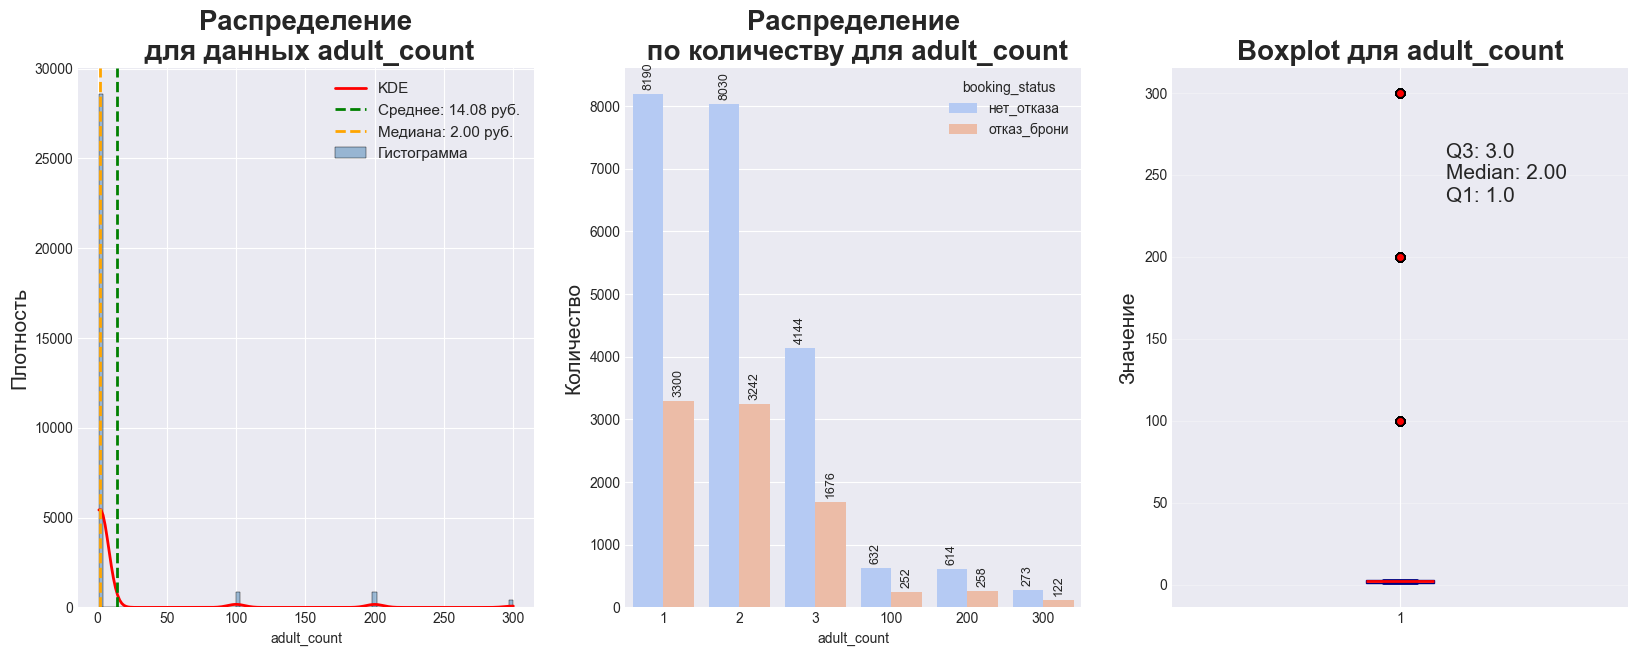

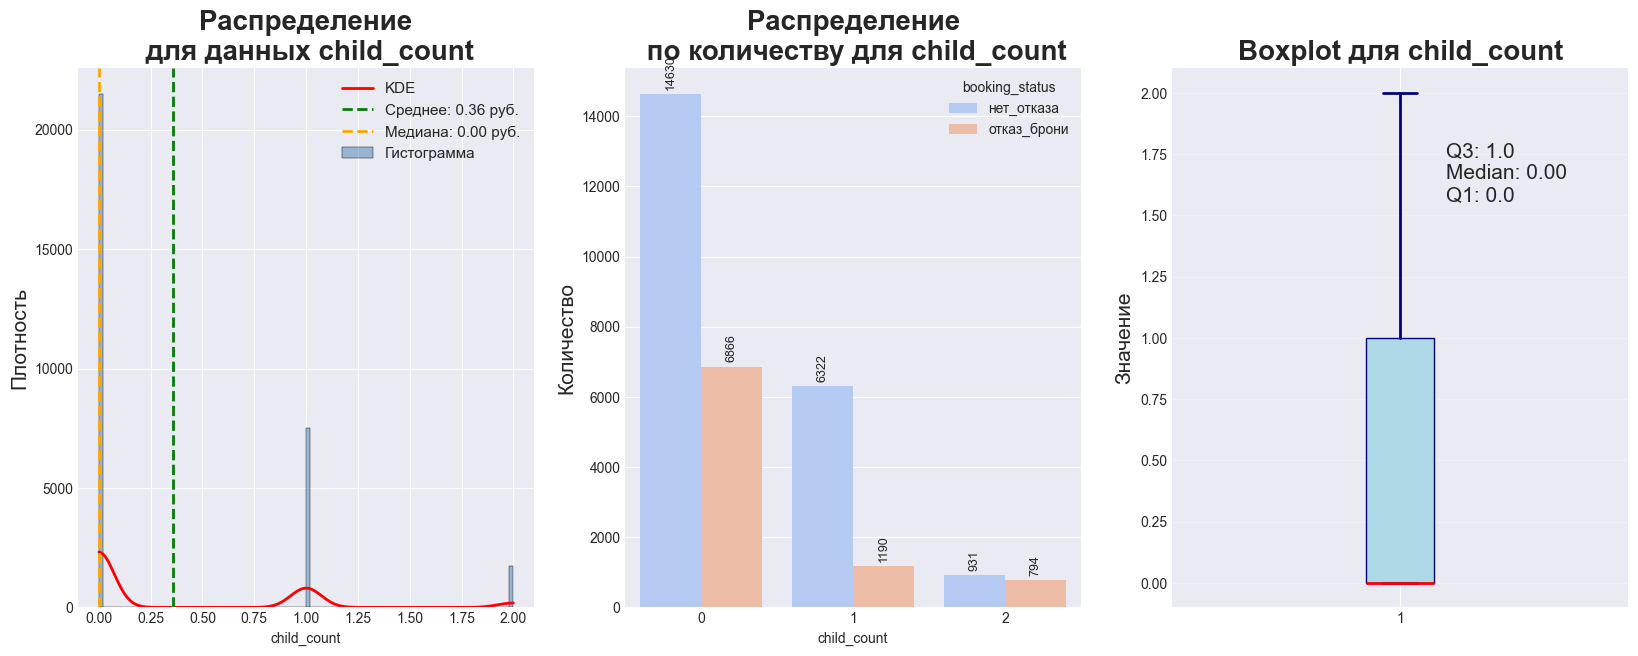

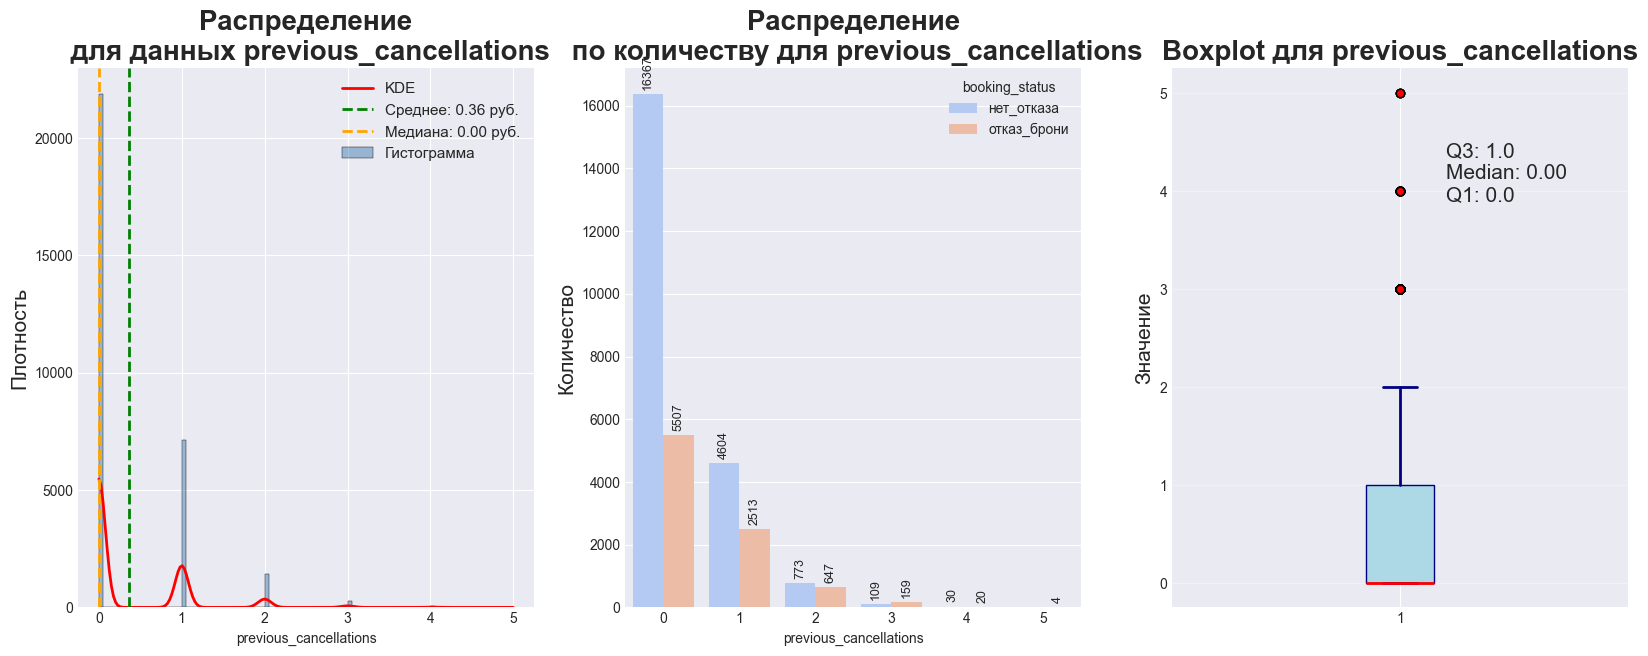

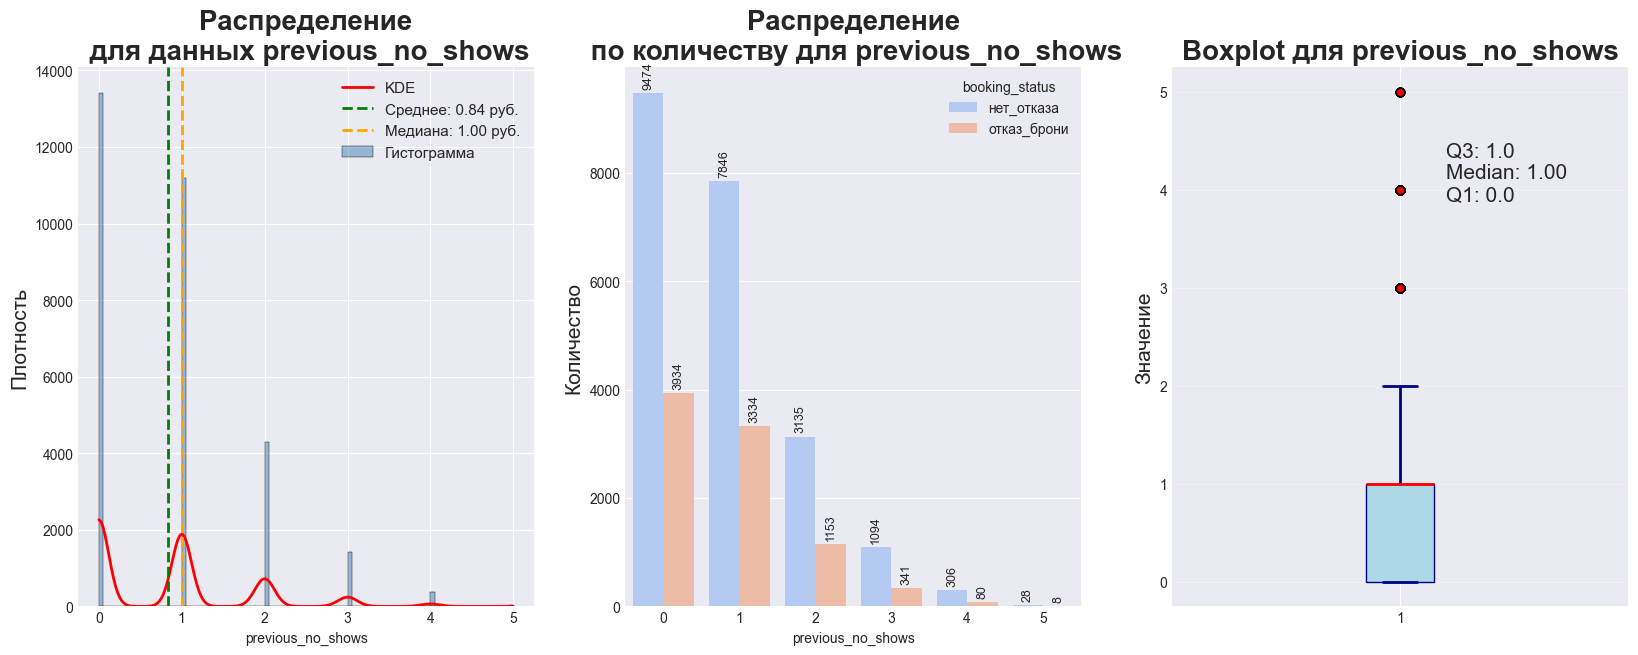

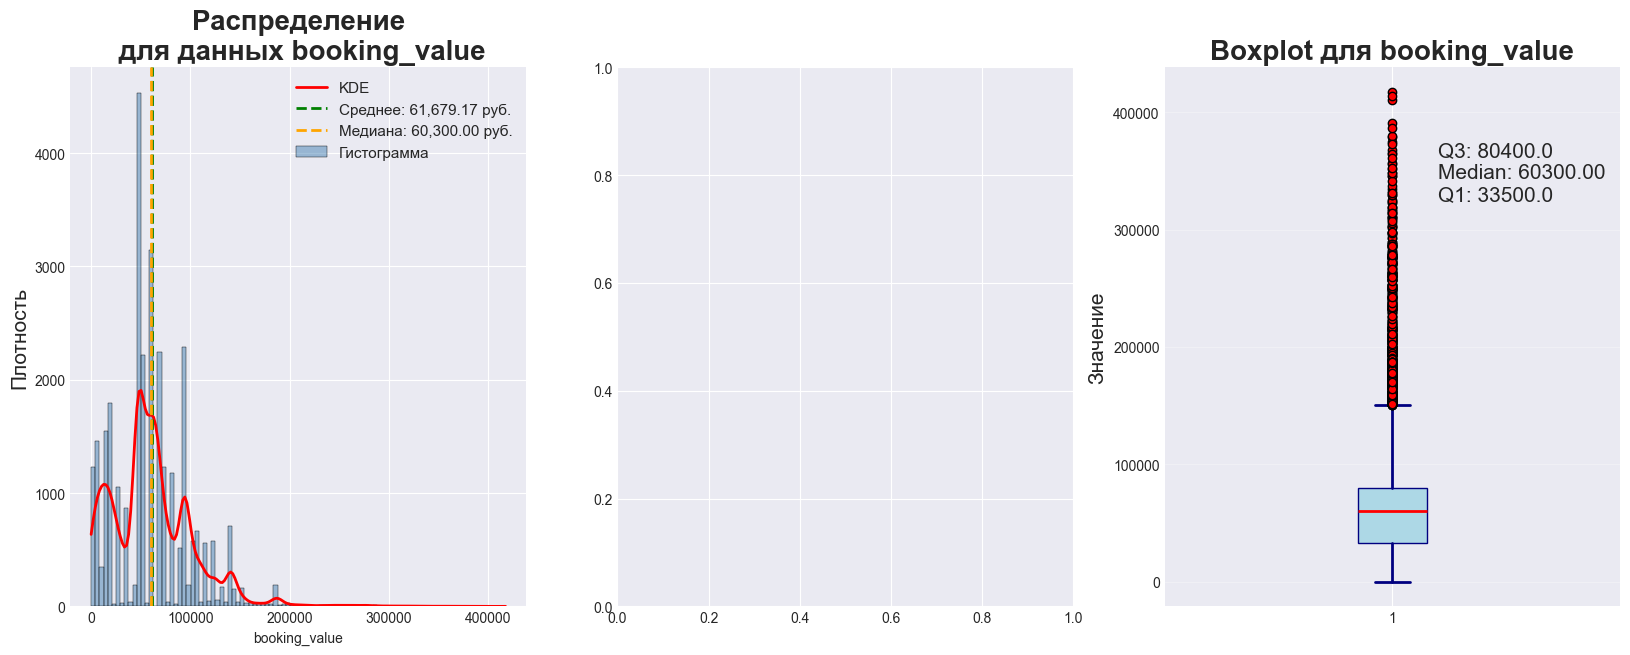

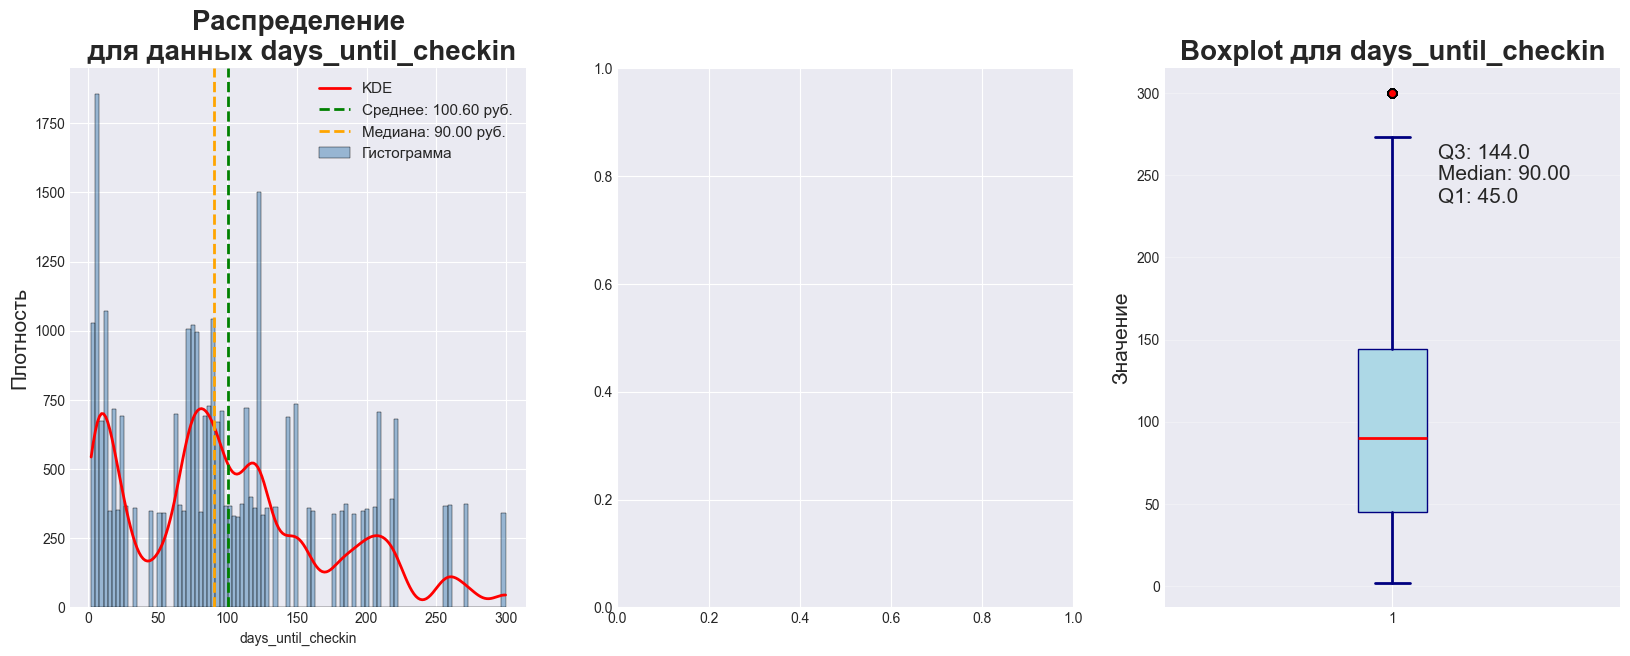

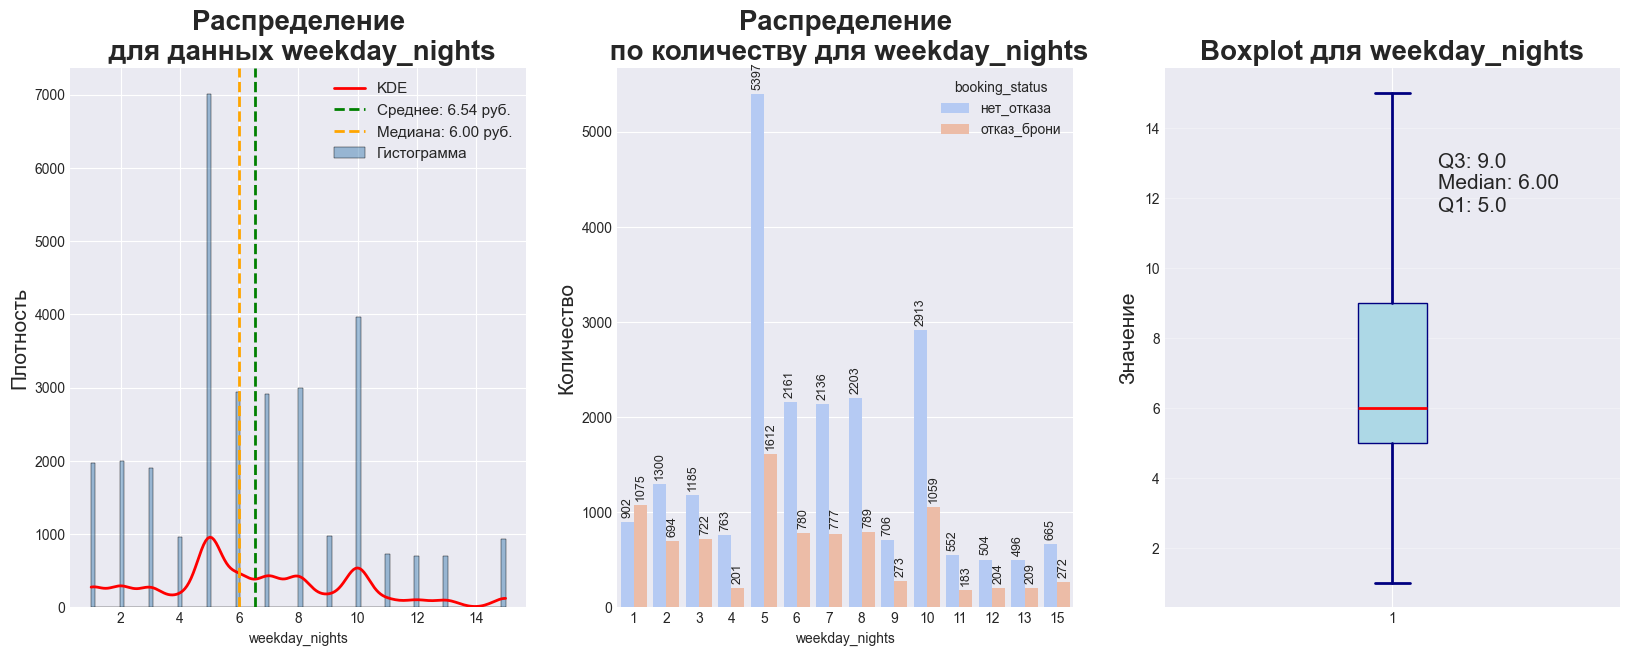

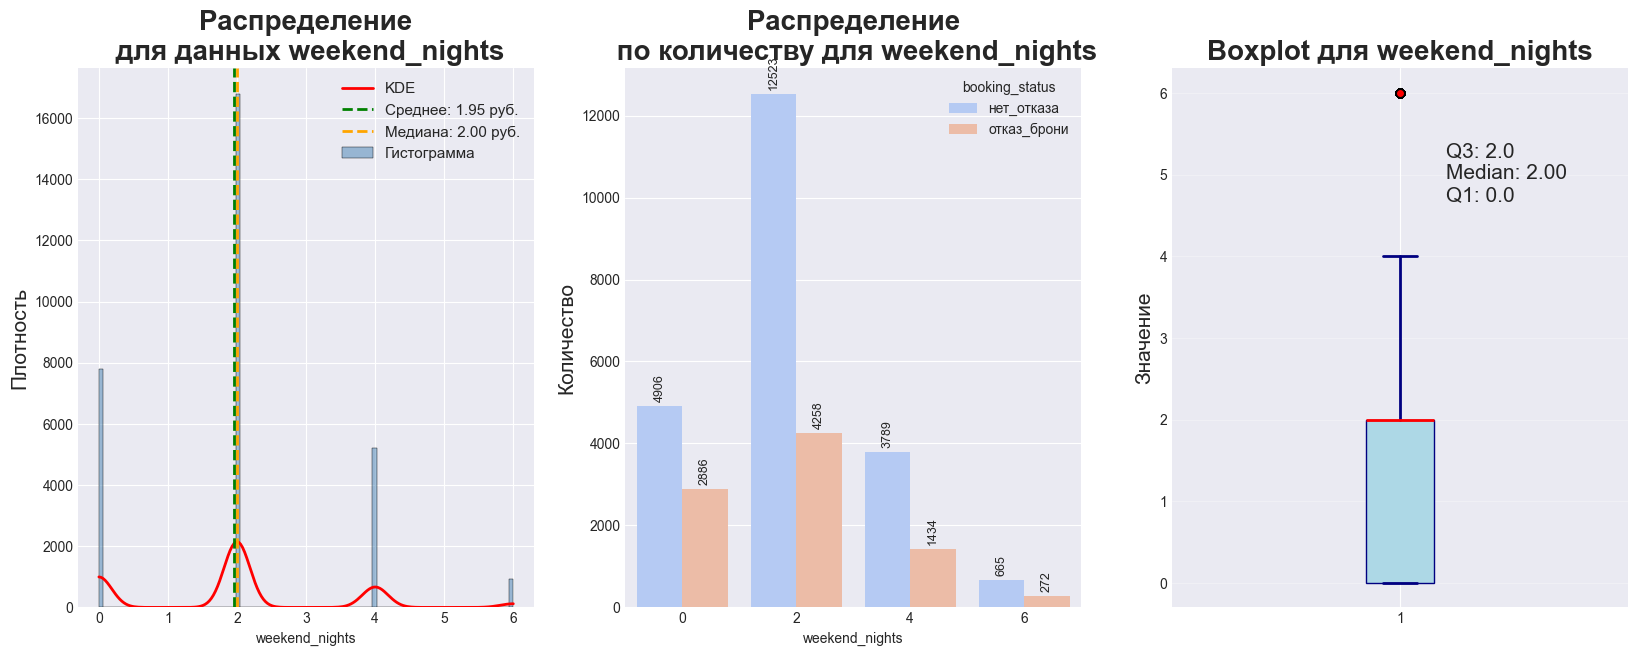

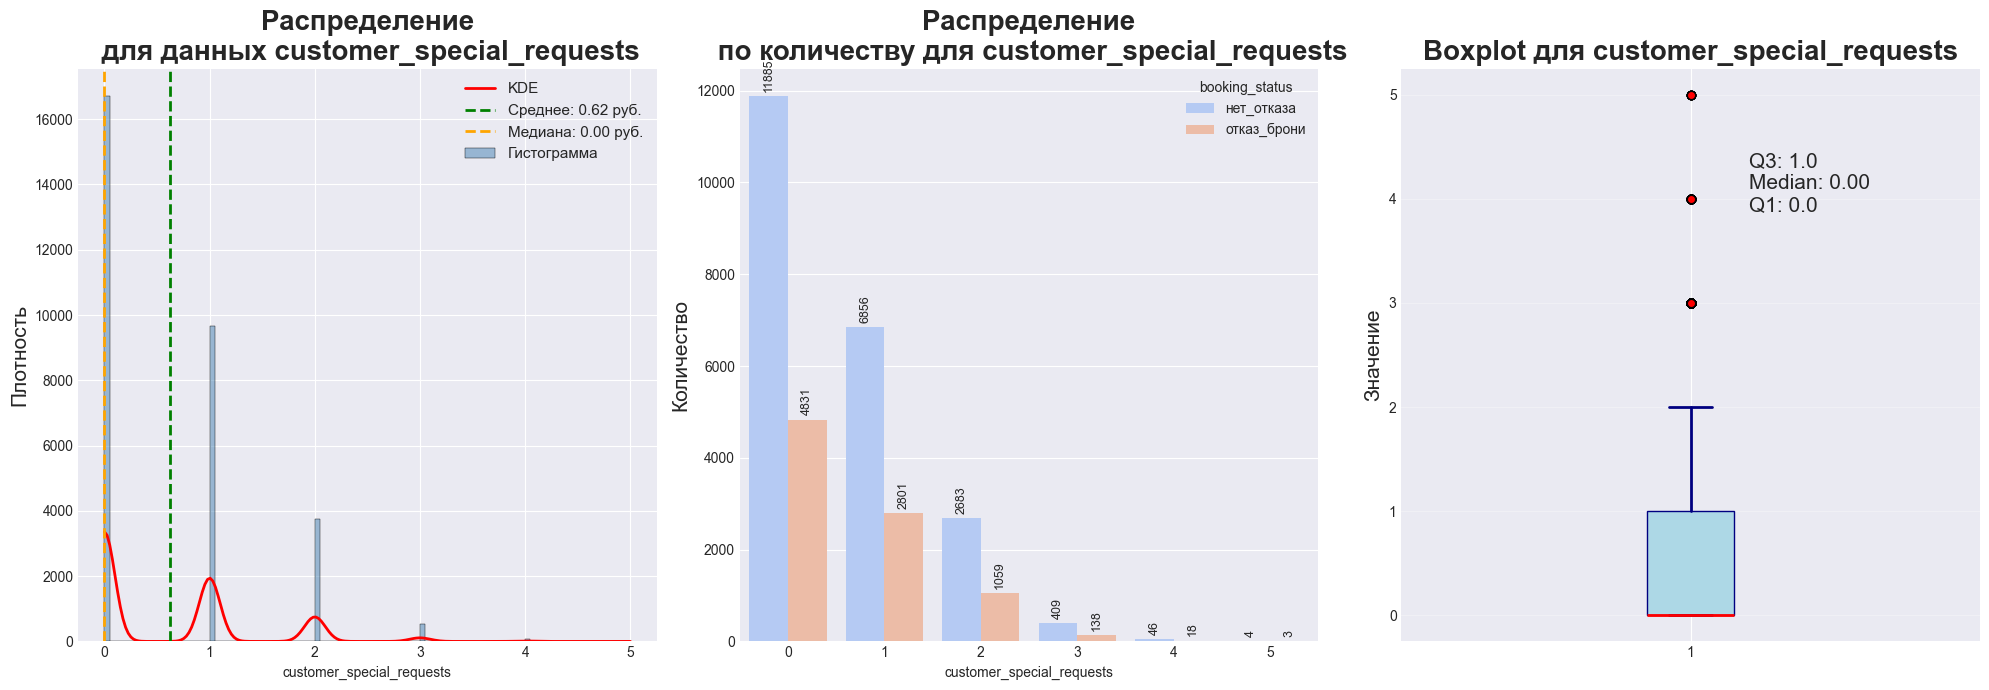

In [18]:
# Выводим графики для датасета df_bookings_drop_dupl
for col in numeric_cols_booking:
    _, axes = plt.subplots(1, 3, figsize=(20, 7))
    print_histplot(df_bookings_drop_dupl, col, axes[0])
    print_countplot(df_bookings_drop_dupl, col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_bookings_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

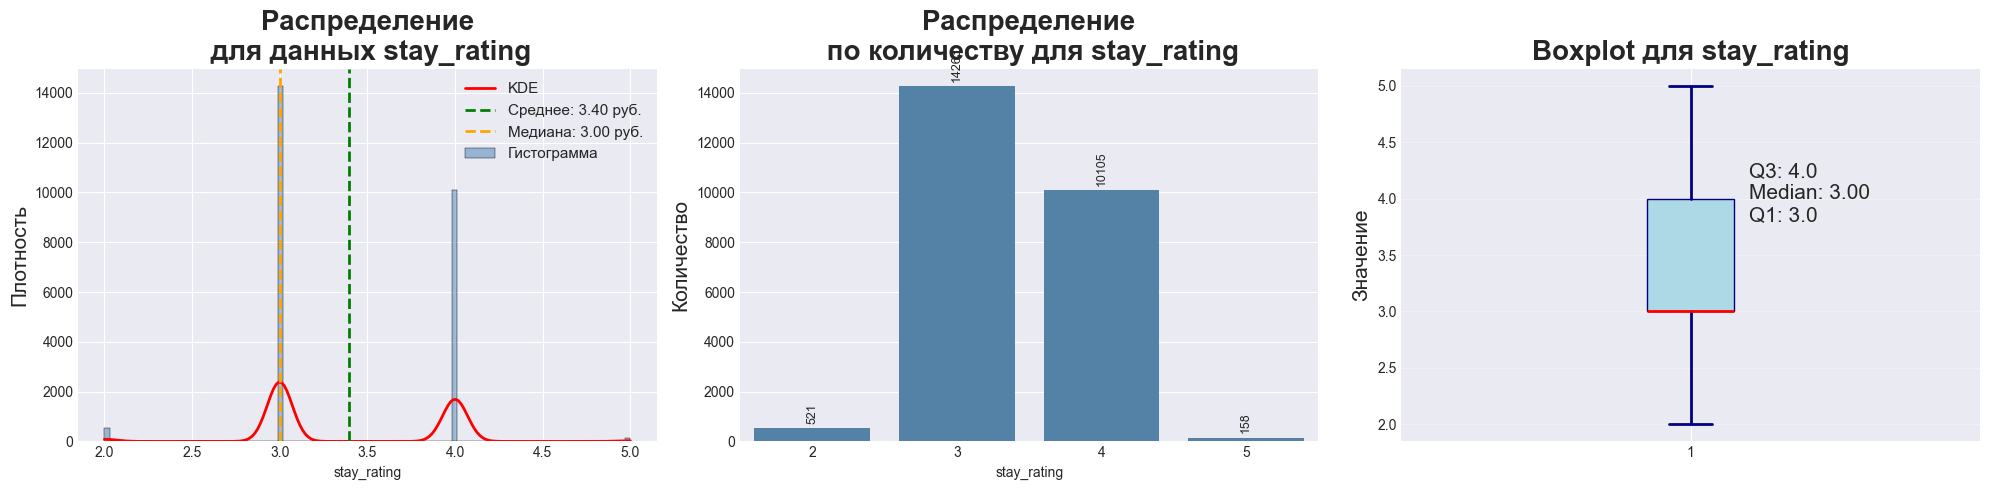

In [19]:
# Выводим графики для датасета df_reviews_drop_dupl
for col in numeric_cols_reviews:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_reviews_drop_dupl, col, axes[0])
    print_countplot(df_reviews_drop_dupl, col, axes[1])
    print_boxplot(df_reviews_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

#### Анализ выбросов

In [20]:
# Функция рассчета выбросов
def mark_iqr_outliers(series): 
    q1 = series.quantile(0.25) 
    q3 = series.quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr 
    upper_bound = q3 + 1.5 * iqr 
    return ~series.between(lower_bound, upper_bound) 

In [21]:
# Определяем количество выбросов для датасета df_bookings
print('Анализ выбросов для датасета df_bookings\n')
for col in numeric_cols_booking: 
    outliers = mark_iqr_outliers(df_bookings_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_bookings

Признак 'adult_count': найдено 2151 выбросов по IQR
Признак 'child_count': найдено 0 выбросов по IQR
Признак 'previous_cancellations': найдено 322 выбросов по IQR
Признак 'previous_no_shows': найдено 1857 выбросов по IQR
Признак 'booking_value': найдено 866 выбросов по IQR
Признак 'days_until_checkin': найдено 340 выбросов по IQR
Признак 'weekday_nights': найдено 0 выбросов по IQR
Признак 'weekend_nights': найдено 937 выбросов по IQR
Признак 'customer_special_requests': найдено 618 выбросов по IQR


In [22]:
# Определяем количество выбросов для датасета df_reviews
print('Анализ выбросов для датасета df_reviews\n')
for col in numeric_cols_reviews: 
    outliers = mark_iqr_outliers(df_reviews_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_reviews

Признак 'stay_rating': найдено 0 выбросов по IQR


In [23]:
# Исправляем выбросы
mask = df_bookings_drop_dupl['adult_count'] >= 100
df_bookings_drop_dupl['adult_count'] = df_bookings_drop_dupl['adult_count'].where(~mask, df_bookings_drop_dupl['adult_count'] // 100)

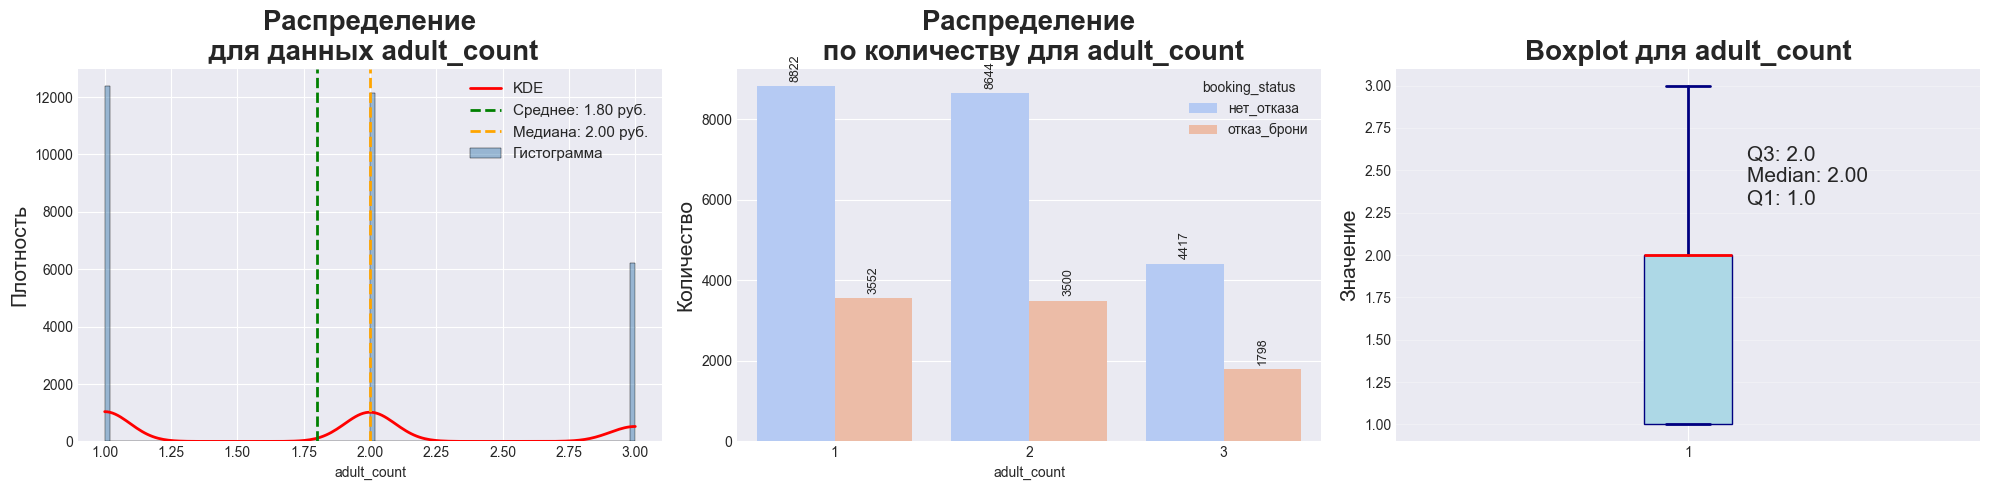

In [24]:
# Выводим графики
_, axes = plt.subplots(1, 3, figsize=(20, 5))
print_histplot(df_bookings_drop_dupl, 'adult_count', axes[0])
print_countplot(df_bookings_drop_dupl, 'adult_count', axes[1], 'booking_status', 'coolwarm')
print_boxplot(df_bookings_drop_dupl, 'adult_count', axes[2])

plt.tight_layout()
plt.show()

#### Анализ категориальных и булевых признаков

In [25]:
# Определяем категориальные признаки
category_cols_booking = df_bookings_drop_dupl.select_dtypes(include=['str', 'object', 'bool']).columns.to_list()
category_cols_booking.remove('booking_id')

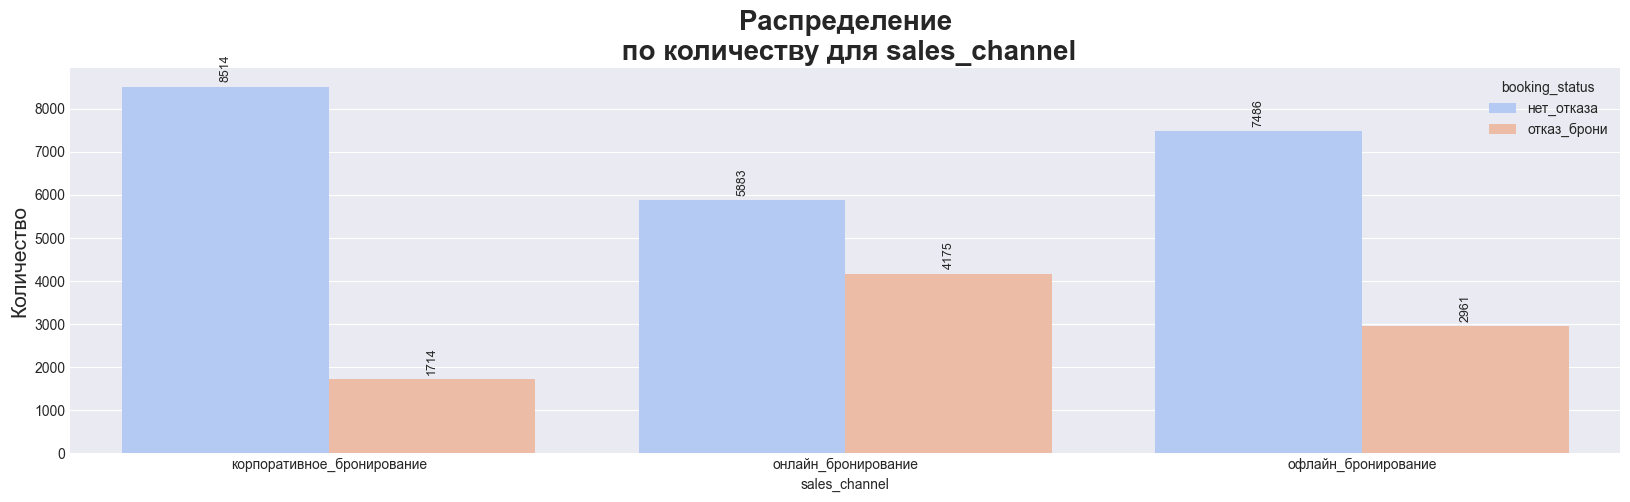

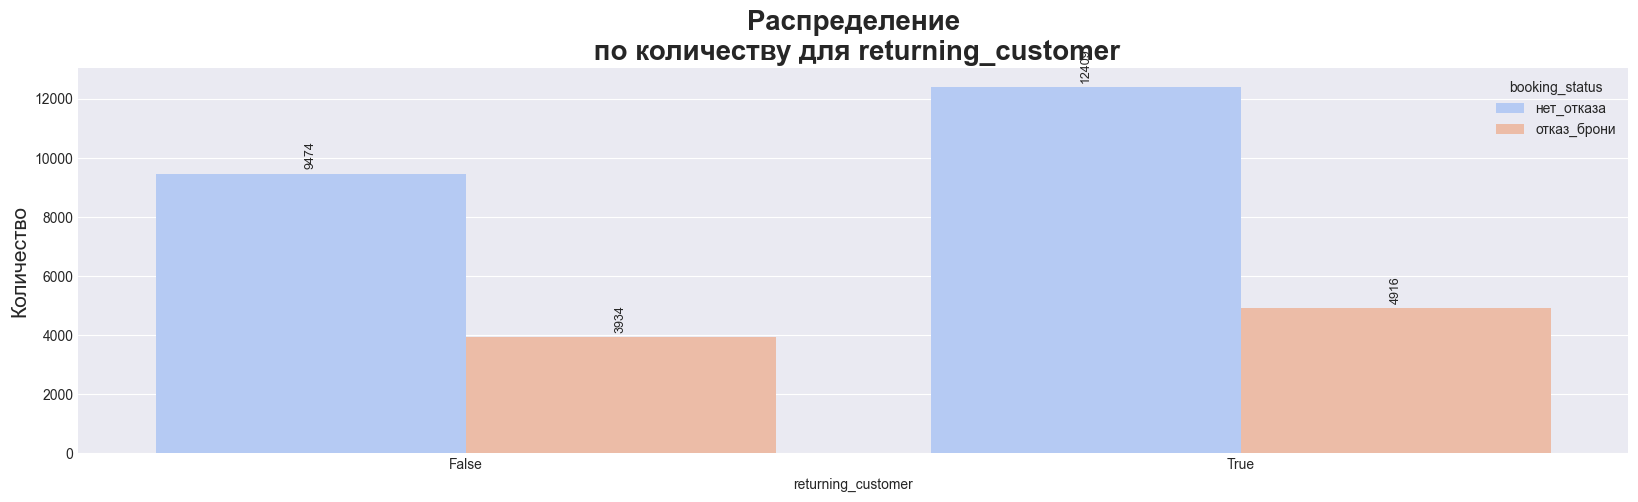

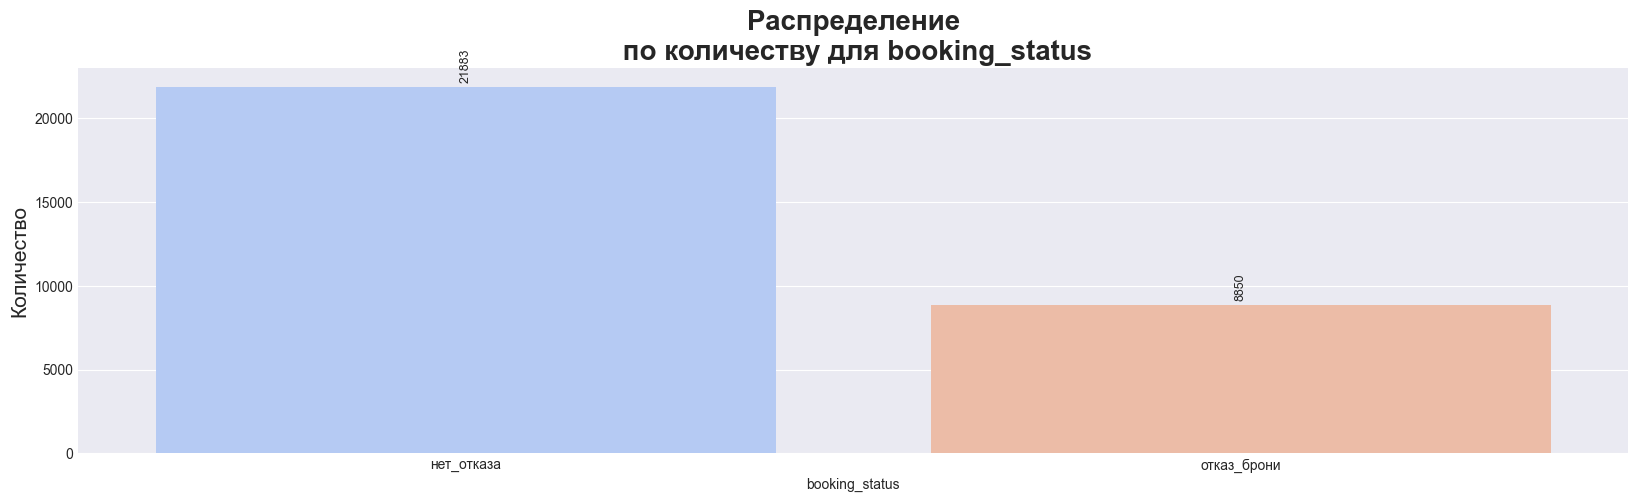

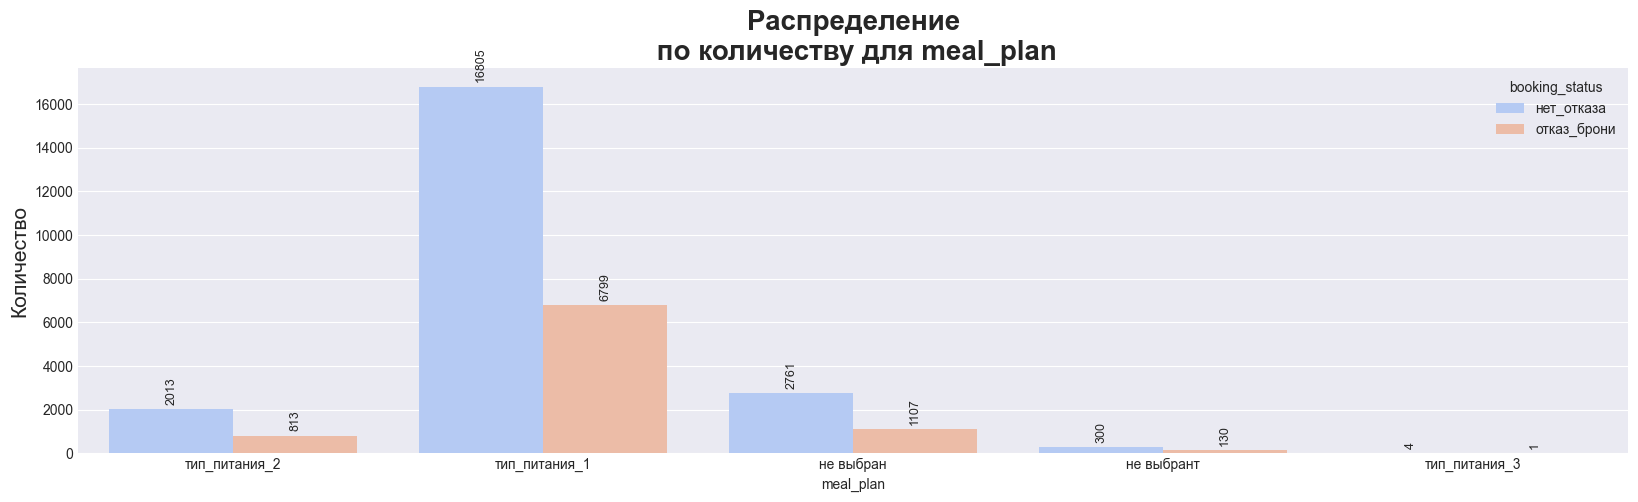

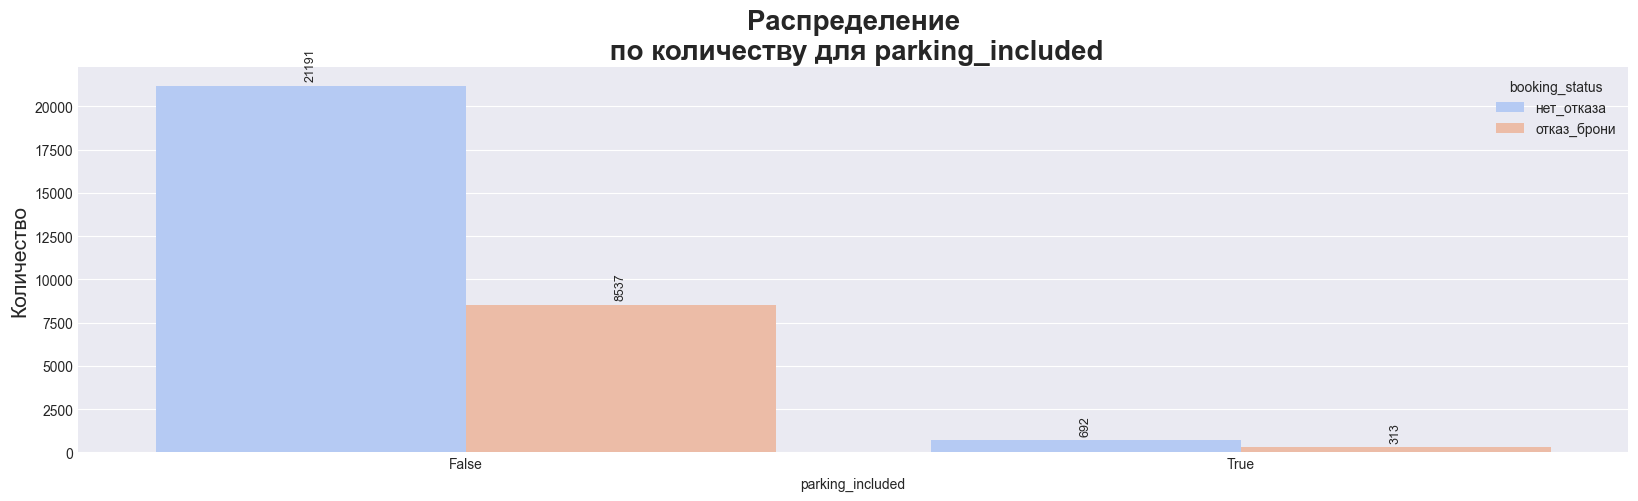

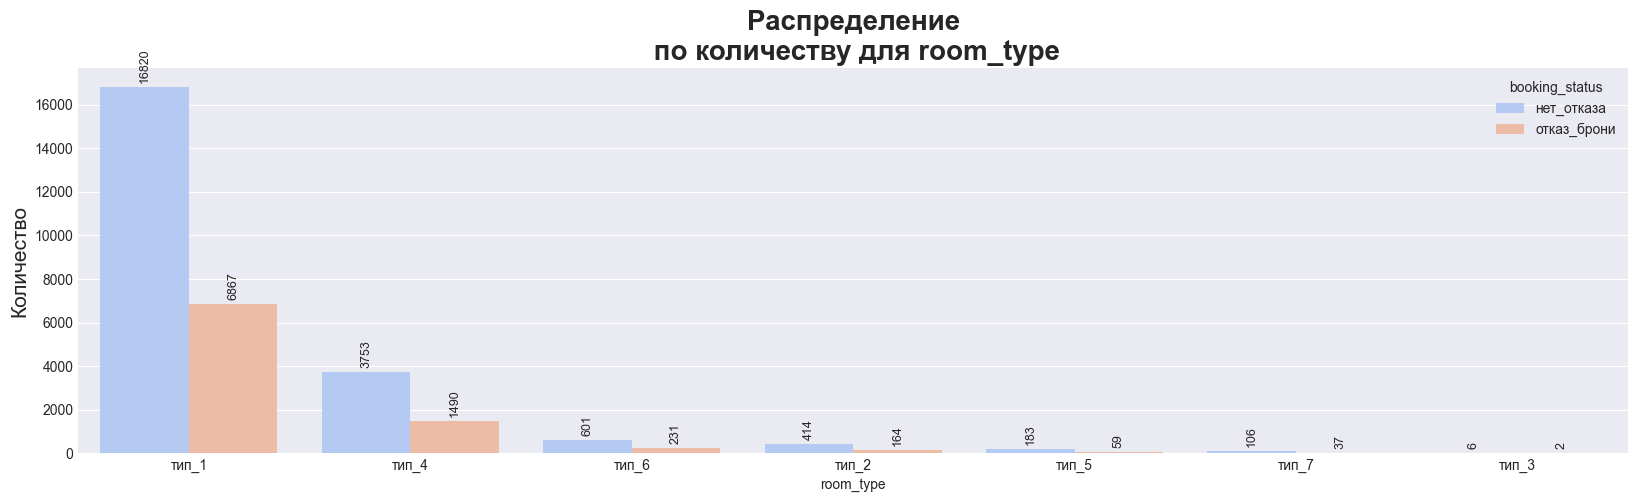

In [26]:
for col in category_cols_booking:
    _, axes = plt.subplots(1, 1, figsize=(20, 5))
    print_countplot(df_bookings_drop_dupl, col, axes, 'booking_status', 'coolwarm')

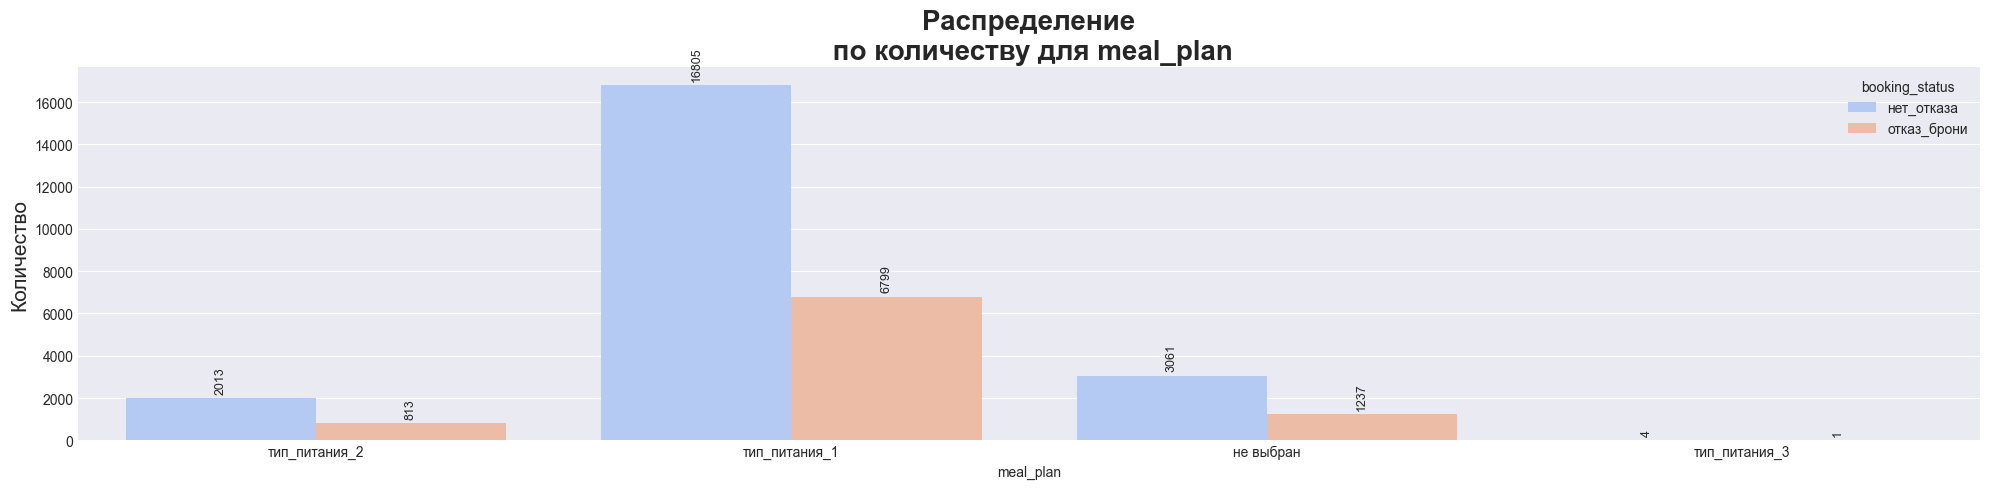

In [27]:
# Исправляем опечатки в признаке 'meal_plan'
df_bookings_drop_dupl['meal_plan'] = df_bookings_drop_dupl['meal_plan'].replace('не выбрант', 'не выбран')

# Выводим графики
_, axes = plt.subplots(1, 1, figsize=(20, 5))
print_countplot(df_bookings_drop_dupl, 'meal_plan', axes, 'booking_status', 'coolwarm')

plt.tight_layout()
plt.show()


#### Анализ признаков с датами

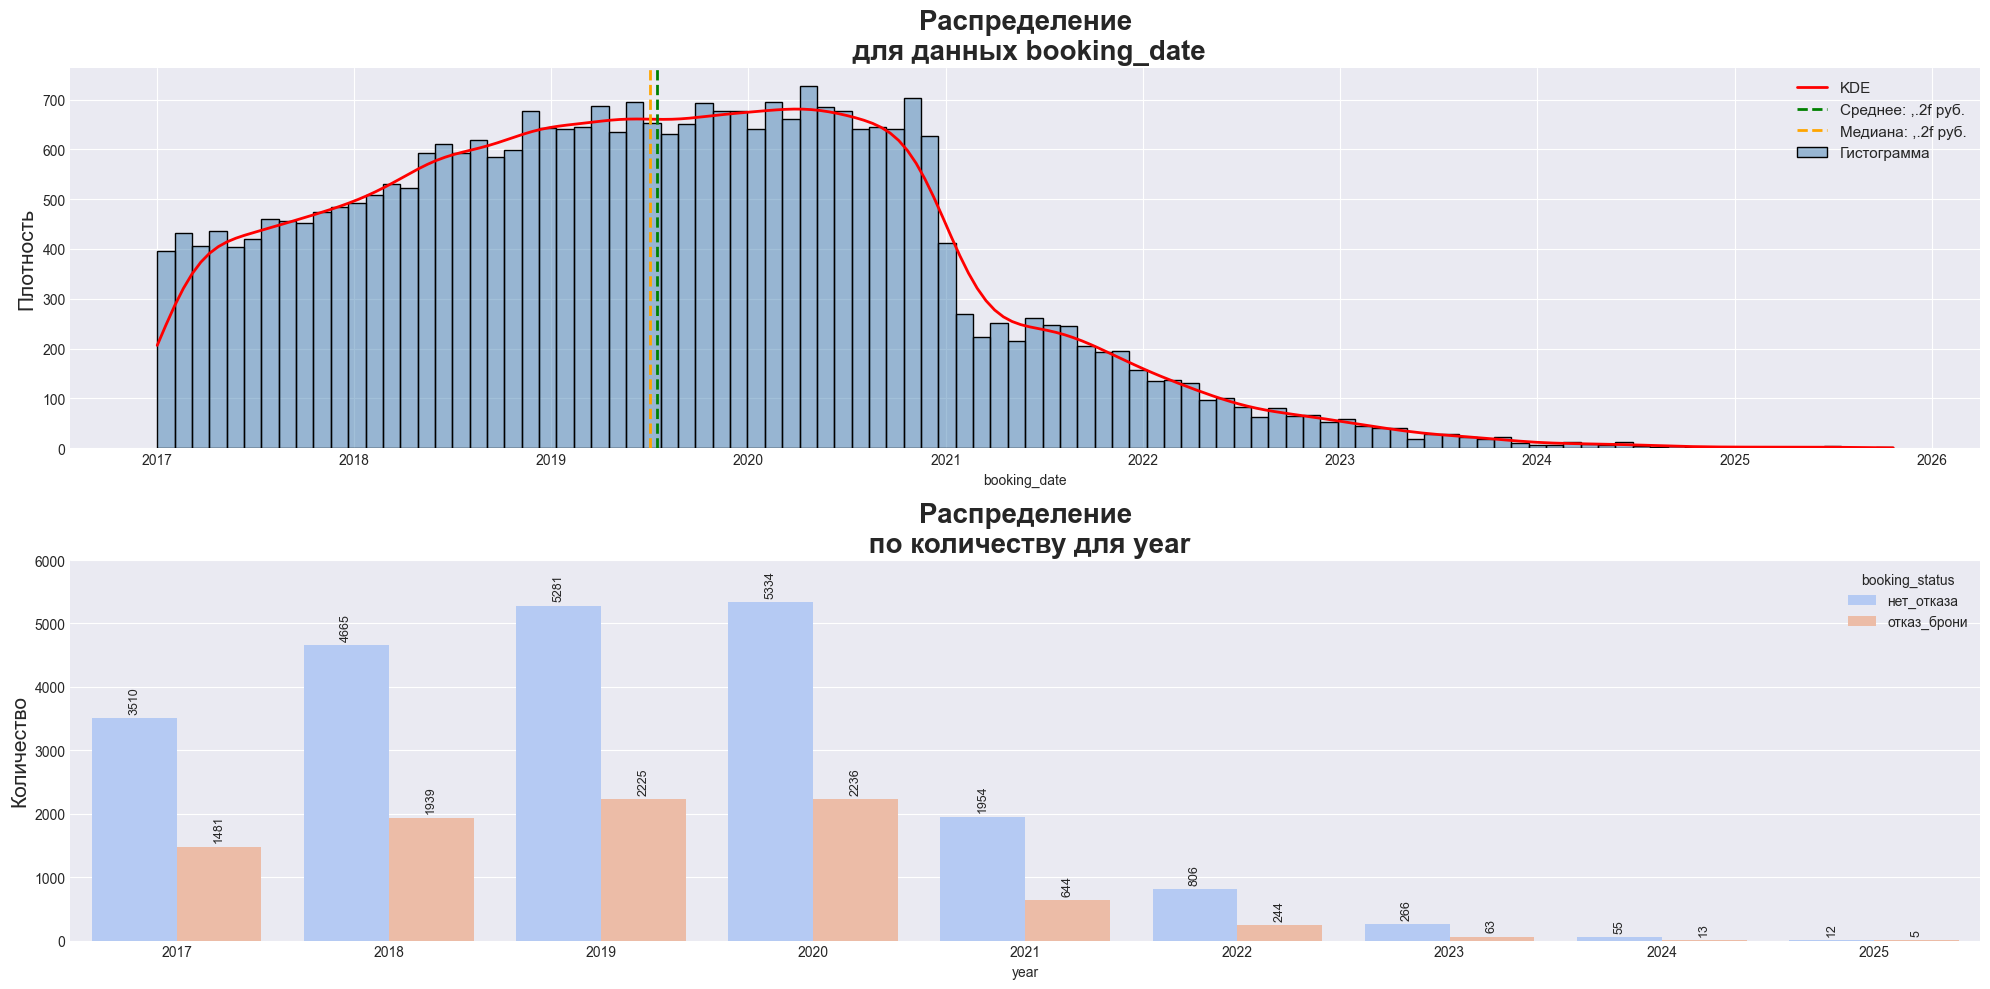

In [28]:
# Выделим из даты год 
df_bookings_date = df_bookings_drop_dupl.copy()
df_bookings_date['year'] = df_bookings_date['booking_date'].dt.strftime('%Y')

# Выводим графики
_, axes = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [1, 1]})
print_histplot(df_bookings_date, 'booking_date', axes[0])
print_countplot(df_bookings_date.sort_values('year'), 'year', axes[1], 'booking_status', 'coolwarm')

axes[1].set_ylim(0, axes[1].get_yticks().max()) 
plt.tight_layout()

#### Анализ корреляционной матрицы

d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable booking_date is large: 2445. Are you sure this is not an interval variable? Analysis for pairs of variables including booking_date can be slow.
  warnings.warn(


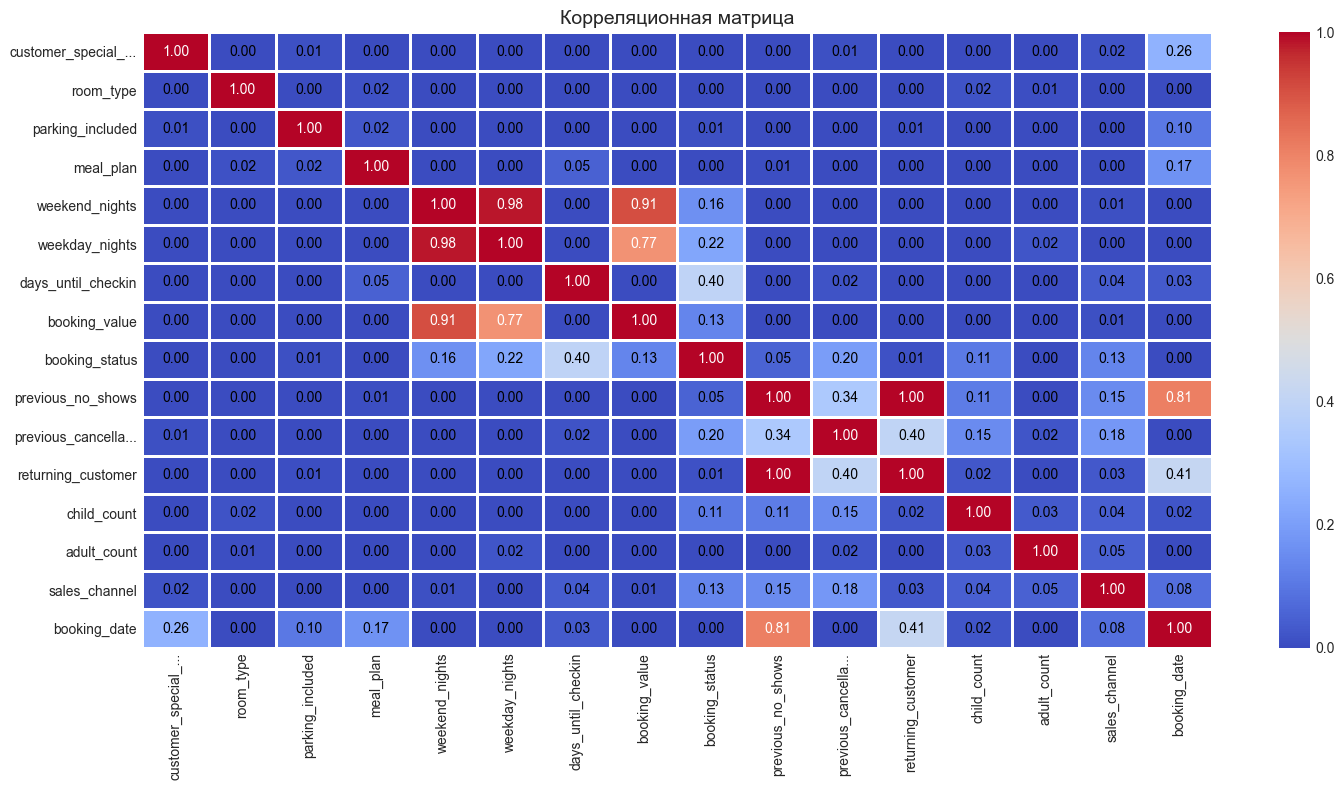

In [29]:
# Удаляем уникальный номер брони
matrix_df = df_bookings_drop_dupl.drop(columns=['booking_id'])

# Рассчитываем матрицу для всех признаков
phik_matrix = matrix_df.phik_matrix(interval_cols=['booking_value'])

# Визуализация матрицы
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1,
    title='Корреляционная матрица',
    figsize=(15, 8),
    color_map='coolwarm'
)

plt.show()

### [1.4 Объединение таблиц <a id=1_4></a>](#content)

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

In [30]:
# Добавляем customer_id в бронирования
customer_map = df_reviews_drop_dupl[['booking_id', 'customer_id']].drop_duplicates().set_index('booking_id')['customer_id']
df_bookings_drop_dupl['customer_id'] = df_bookings_drop_dupl['booking_id'].map(customer_map)

# Разделяем: те, у кого есть customer_id (для слияния) и те, у кого нет (оставляем как есть)
has_customer = df_bookings_drop_dupl['customer_id'].notna()
df_bookings_with_customer = df_bookings_drop_dupl[has_customer].copy()
df_bookings_without_customer = df_bookings_drop_dupl[~has_customer].copy()

# Сортируем для merge_asof
df_bookings_sorted = df_bookings_with_customer.sort_values(
    ['booking_date', 'customer_id'], ascending=[True, True]
).reset_index(drop=True)

df_reviews_sorted = df_reviews_drop_dupl.sort_values(
    ['review_date', 'customer_id'], ascending=[True, True]
).reset_index(drop=True)

# Выполняем слияние
merged = pd.merge_asof(
    df_bookings_sorted,
    df_reviews_sorted[['customer_id', 'review_date', 'stay_rating', 'review_text']],
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False
)

# Объединяем с теми записями, у которых не было customer_id (у них добавленные колонки будут NaN)
df_merge_booking = pd.concat([merged, df_bookings_without_customer], ignore_index=True)

In [31]:
# Выводим общую информацию об объеденненой таблице
primary_info(df_merge_booking, 'df_merge_bookings')

Информация о таблице: df_merge_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.00,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,INN22445,2017-01-01,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.00,85,6,2,не выбран,False,тип_1,0,C12041,NaT,NaN,NaN
2,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.00,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN
3,INN14477,2017-01-01,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.00,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaT,NaN,NaN
4,INN17387,2017-01-01,офлайн_бронирование,2,0,True,1,1,нет_отказа,73 700.00,79,9,2,тип_питания_1,False,тип_1,2,C9324,NaT,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 30733 entries, 0 to 30732
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id                 30733 non-null  str          
 1   booking_date               30733 non-null  datetime64[s]
 2   sales_channel              30733 non-null  str          
 3   adult_count                30733 non-null  int64        
 4   child_count                30733 non-null  int64        
 5   returning_customer         30733 non-null  bool         
 6   previous_cancellations     30733 non-null  int64        
 7   previous_no_shows          30733 non-null  int64        
 8   booking_status             30733 non-null  str          
 9   booking_value              30733 non-null  float64      
 10  days_until_checkin         30733 non-null  int64        
 11  weekday_nights             30733 non-null  int64        
 12  weekend_nights             30

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
booking_id,30733,30733,INN21754,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,30733,NaN,NaN,NaN,2019-07-15 02:59:10,2017-01-01 00:00:00,2018-06-11 00:00:00,2019-07-03 00:00:00,2020-07-05 00:00:00,2025-10-22 00:00:00,NaN
sales_channel,30733,3,офлайн_бронирование,10447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,30 733.00,NaN,NaN,NaN,1.80,1.00,1.00,2.00,2.00,3.00,0.75
child_count,30 733.00,NaN,NaN,NaN,0.36,0.00,0.00,0.00,1.00,2.00,0.58
returning_customer,30733,2,True,17325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,30 733.00,NaN,NaN,NaN,0.36,0.00,0.00,0.00,1.00,5.00,0.63
previous_no_shows,30 733.00,NaN,NaN,NaN,0.84,0.00,0.00,1.00,1.00,5.00,0.93
booking_status,30733,2,нет_отказа,21883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,30 733.00,NaN,NaN,NaN,61 679.17,0.00,33 500.00,60 300.00,80 400.00,417 221.20,42 737.29


### [1.5 Создание новых признаков <a id=1_5></a>](#content)

- Сделать выводы о созданных признаках.

In [32]:
# Объявляем множество из стоп-слов русского языка
russian_stopwords = set(stopwords.words('russian'))

# Создаем базовую токенизацию
_word_re = re.compile(r'[а-яё]+', re.IGNORECASE)

# Объявляем функцию для токенизации текста
def tokenize_ru(text):
    return _word_re.findall(str(text).lower())

# Объявляем функцию для удаления стоп-слов
def remove_stopwords(text):
    return " ".join([word for word in text if word not in russian_stopwords])

In [33]:
def add_booking_features(df):
    """
    Создаем дополнительные признаки для датафрейма
    """
    df = df.copy()

    # Общая длительность прибывания
    df['total_nights'] = df['weekday_nights'] + df['weekend_nights']

    # Стоимость одной ночи за гостя
    guests_count = df['adult_count'] + df['child_count'] + 1 # защита от нуля и появления ошибки ZeroDivisionError
    nights_count = df['total_nights'].replace(0, 1) # временная замена для расчета
    df['price_per_guest_per_night'] = df['booking_value'] / (guests_count * nights_count)

    # Категоризация дней до заезда
    bins = [-1, 7, 30, 90, 1000]
    labels = ['very_soon', 'soon', 'medium', 'long_ahead']
    df['days_until_checkin_bucket'] = pd.cut(
        df['days_until_checkin'],
        bins=bins,
        labels=labels,
        right=True
    )

    return df

In [34]:
def feature_extraction_text(df):
    """
    Функция токенезирует признак с отзывами
    """
    df = df.copy()

    # Заполняем пропуски пустой строкой, чтобы TF-IDF не падал
    texts = df['review_text'].fillna('').astype(str)

    processed_texts = []
    for text in texts:
        tokens = tokenize_ru(text)
        filtered_tokens = remove_stopwords(tokens)
        processed_texts.append(filtered_tokens)

    vectorizer = TfidfVectorizer(
        max_features=50,
        ngram_range=(1, 2)
    )

    tfidf_matrix = vectorizer.fit_transform(processed_texts)

    # Превращаем в DataFrame с понятными именами колонок
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f'review_tfidf_{i}' for i in range(tfidf_matrix.shape[1])],
        index=df.index
    )

    return pd.concat([df.drop(columns=['review_text']), tfidf_df], axis=1)

In [35]:
def extract_time_features(df):
    """Функция для извлечения новых признаков из datetime"""
    df = df.copy()
    
    for col in ['booking_date', 'review_date']:
        # Если дата пропущена, заполняем дефолтной эпохой, чтобы .dt работал без ошибок
        temp_date = df[col].fillna(pd.Timestamp('1970-01-01'))
        
        df[f'{col}_year'] = temp_date.dt.year
        df[f'{col}_month'] = temp_date.dt.month
        df[f'{col}_day_of_week'] = temp_date.dt.dayofweek 
        
        # Циклические признаки для месяца
        df[f'{col}_month_sin'] = np.sin(2 * np.pi * df[f'{col}_month'] / 12)
        df[f'{col}_month_cos'] = np.cos(2 * np.pi * df[f'{col}_month'] / 12)
        
        # Удаляем исходный признак
        df.drop([col], axis=1, inplace=True)

    return df

In [36]:
# Создаем новые признаки и токенизацию отзывов
df_merge_booking_with_features = add_booking_features(df_merge_booking)
df_merge_booking_with_features = extract_time_features(df_merge_booking_with_features)
df_merge_booking_with_features = feature_extraction_text(df_merge_booking_with_features)
df_merge_booking_with_features

,booking_id,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,stay_rating,total_nights,price_per_guest_per_night,days_until_checkin_bucket,booking_date_year,booking_date_month,booking_date_day_of_week,booking_date_month_sin,booking_date_month_cos,review_date_year,review_date_month,review_date_day_of_week,review_date_month_sin,review_date_month_cos,review_tfidf_0,review_tfidf_1,review_tfidf_2,review_tfidf_3,review_tfidf_4,review_tfidf_5,review_tfidf_6,review_tfidf_7,review_tfidf_8,review_tfidf_9,review_tfidf_10,review_tfidf_11,review_tfidf_12,review_tfidf_13,review_tfidf_14,review_tfidf_15,review_tfidf_16,review_tfidf_17,review_tfidf_18,review_tfidf_19,review_tfidf_20,review_tfidf_21,review_tfidf_22,review_tfidf_23,review_tfidf_24,review_tfidf_25,review_tfidf_26,review_tfidf_27,review_tfidf_28,review_tfidf_29,review_tfidf_30,review_tfidf_31,review_tfidf_32,review_tfidf_33,review_tfidf_34,review_tfidf_35,review_tfidf_36,review_tfidf_37,review_tfidf_38,review_tfidf_39,review_tfidf_40,review_tfidf_41,review_tfidf_42,review_tfidf_43,review_tfidf_44,review_tfidf_45,review_tfidf_46,review_tfidf_47,review_tfidf_48,review_tfidf_49
0,INN21754,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.00,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,10,1 116.67,long_ahead,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,INN22445,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.00,85,6,2,не выбран,False,тип_1,0,C12041,NaN,8,2 966.67,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,INN11824,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.00,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,1,1 675.00,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,INN14477,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.00,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,7,3 350.00,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,INN17387,офлайн_бронирование,2,0,True,1,1,нет_отказа,73 700.00,79,9,2,тип_питания_1,False,тип_1,2,C9324,NaN,11,2 233.33,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30728,INN30708,офлайн_бронирование,2,1,False,0,0,отказ_брони,13 400.00,199,2,0,не выбран,False,тип_1,0,NaN,NaN,2,1 675.00,long_ahead,2017,8,6,-0.87,-0.50,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0

### [1.6 Анализ итоговой таблицы <a id=1_6></a>](#content)

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

In [37]:
# Выводим предворительную информацию
primary_info(df_merge_booking_with_features, 'df_merge_booking_with_features')

Информация о таблице: df_merge_booking_with_features


,booking_id,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,stay_rating,total_nights,price_per_guest_per_night,days_until_checkin_bucket,booking_date_year,booking_date_month,booking_date_day_of_week,booking_date_month_sin,booking_date_month_cos,review_date_year,review_date_month,review_date_day_of_week,review_date_month_sin,review_date_month_cos,review_tfidf_0,review_tfidf_1,review_tfidf_2,review_tfidf_3,review_tfidf_4,review_tfidf_5,review_tfidf_6,review_tfidf_7,review_tfidf_8,review_tfidf_9,review_tfidf_10,review_tfidf_11,review_tfidf_12,review_tfidf_13,review_tfidf_14,review_tfidf_15,review_tfidf_16,review_tfidf_17,review_tfidf_18,review_tfidf_19,review_tfidf_20,review_tfidf_21,review_tfidf_22,review_tfidf_23,review_tfidf_24,review_tfidf_25,review_tfidf_26,review_tfidf_27,review_tfidf_28,review_tfidf_29,review_tfidf_30,review_tfidf_31,review_tfidf_32,review_tfidf_33,review_tfidf_34,review_tfidf_35,review_tfidf_36,review_tfidf_37,review_tfidf_38,review_tfidf_39,review_tfidf_40,review_tfidf_41,review_tfidf_42,review_tfidf_43,review_tfidf_44,review_tfidf_45,review_tfidf_46,review_tfidf_47,review_tfidf_48,review_tfidf_49
0,INN21754,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.00,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,10,1 116.67,long_ahead,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,INN22445,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.00,85,6,2,не выбран,False,тип_1,0,C12041,NaN,8,2 966.67,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,INN11824,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.00,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,1,1 675.00,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,INN14477,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.00,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,7,3 350.00,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,INN17387,офлайн_бронирование,2,0,True,1,1,нет_отказа,73 700.00,79,9,2,тип_питания_1,False,тип_1,2,C9324,NaN,11,2 233.33,medium,2017,1,6,0.50,0.87,1970,1,3,0.50,0.87,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


<class 'pandas.DataFrame'>
RangeIndex: 30733 entries, 0 to 30732
Data columns (total 81 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   booking_id                 30733 non-null  str     
 1   sales_channel              30733 non-null  str     
 2   adult_count                30733 non-null  int64   
 3   child_count                30733 non-null  int64   
 4   returning_customer         30733 non-null  bool    
 5   previous_cancellations     30733 non-null  int64   
 6   previous_no_shows          30733 non-null  int64   
 7   booking_status             30733 non-null  str     
 8   booking_value              30733 non-null  float64 
 9   days_until_checkin         30733 non-null  int64   
 10  weekday_nights             30733 non-null  int64   
 11  weekend_nights             30733 non-null  int64   
 12  meal_plan                  30733 non-null  str     
 13  parking_included           30733 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,30733,30733,INN21754,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,30733,3,офлайн_бронирование,10447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,30 733.00,NaN,NaN,NaN,1.80,0.75,1.00,1.00,2.00,2.00,3.00
child_count,30 733.00,NaN,NaN,NaN,0.36,0.58,0.00,0.00,0.00,1.00,2.00
returning_customer,30733,2,True,17325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
review_tfidf_45,30 733.00,NaN,NaN,NaN,0.01,0.07,0.00,0.00,0.00,0.00,0.39
review_tfidf_46,30 733.00,NaN,NaN,NaN,0.01,0.07,0.00,0.00,0.00,0.00,0.87
review_tfidf_47,30 733.00,NaN,NaN,NaN,0.01,0.06,0.00,0.00,0.00,0.00,0.73
review_tfidf_48,30 733.00,NaN,NaN,NaN,0.01,0.05,0.00,0.00,0.00,0.00,0.30


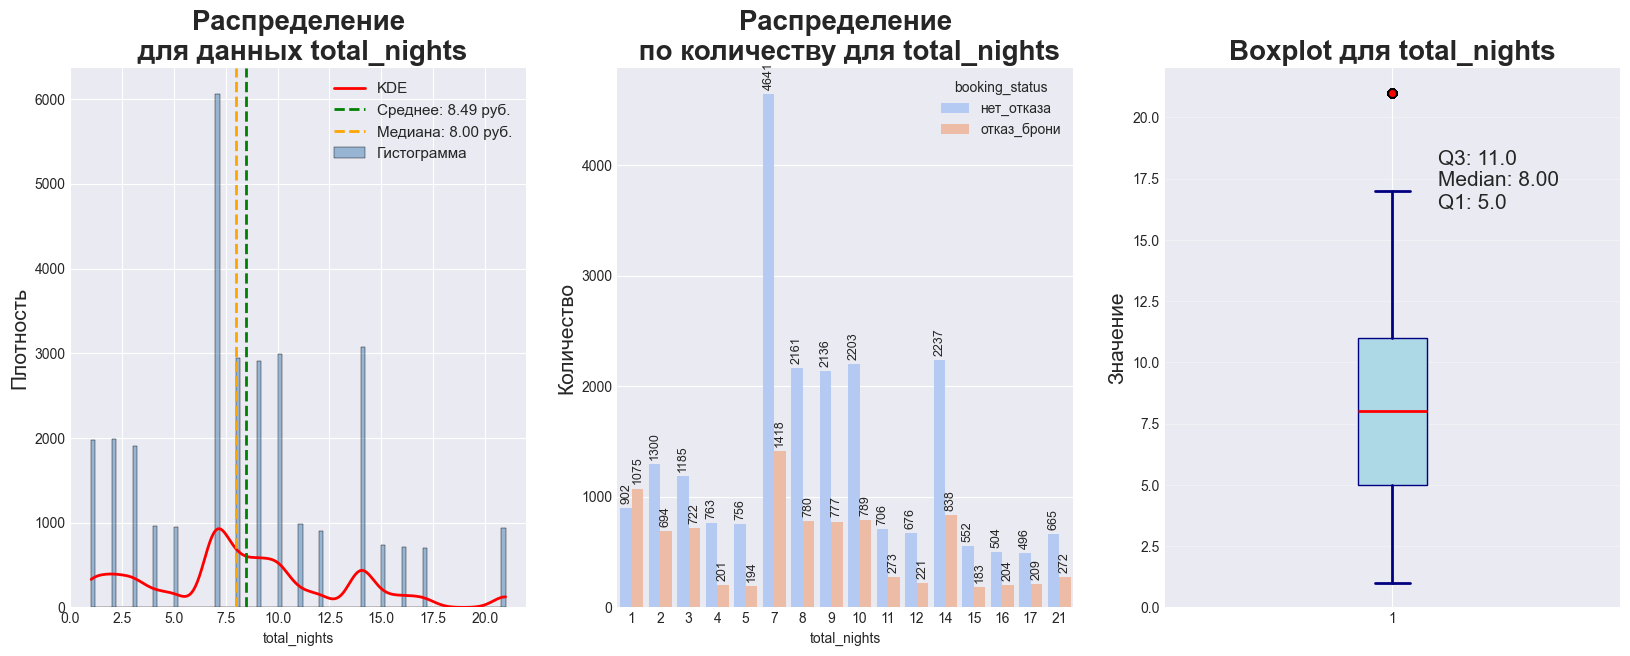

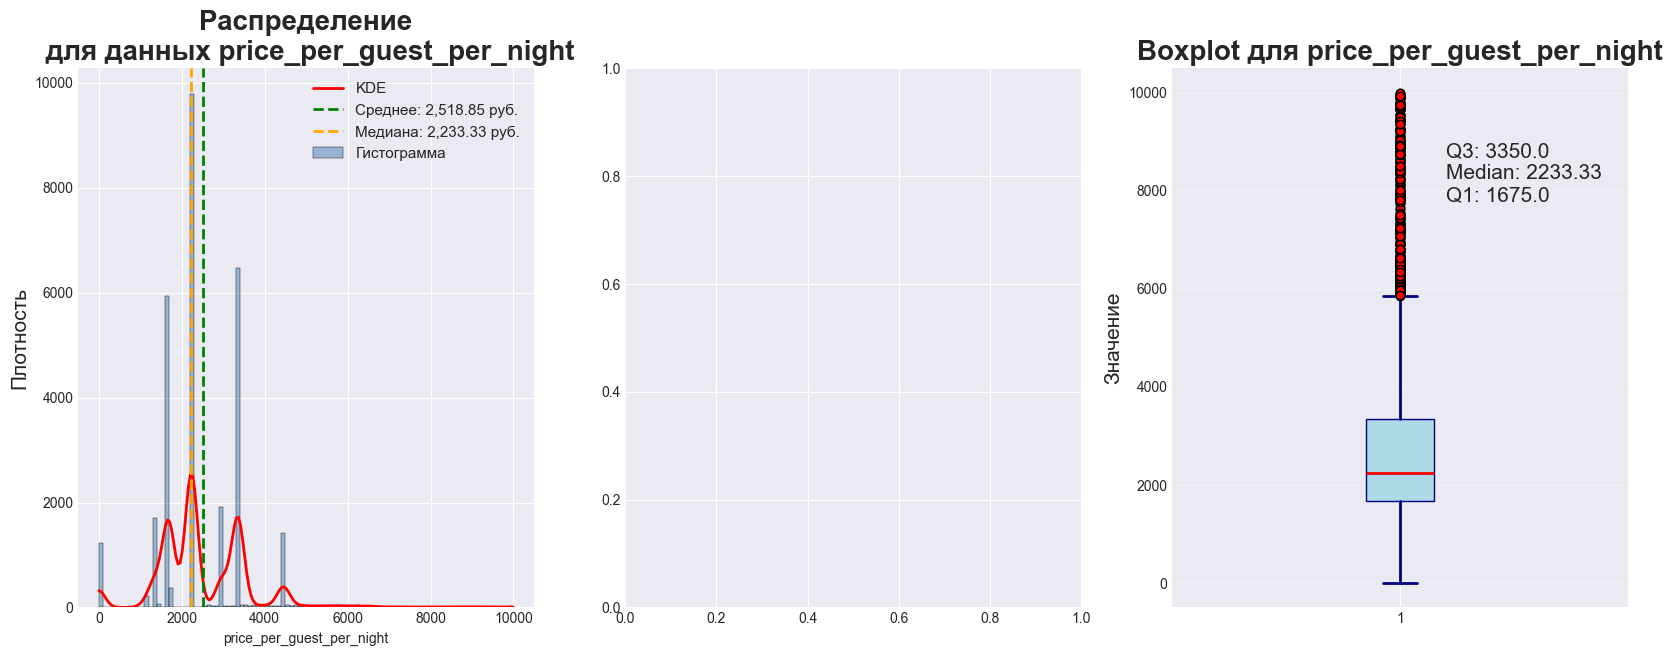

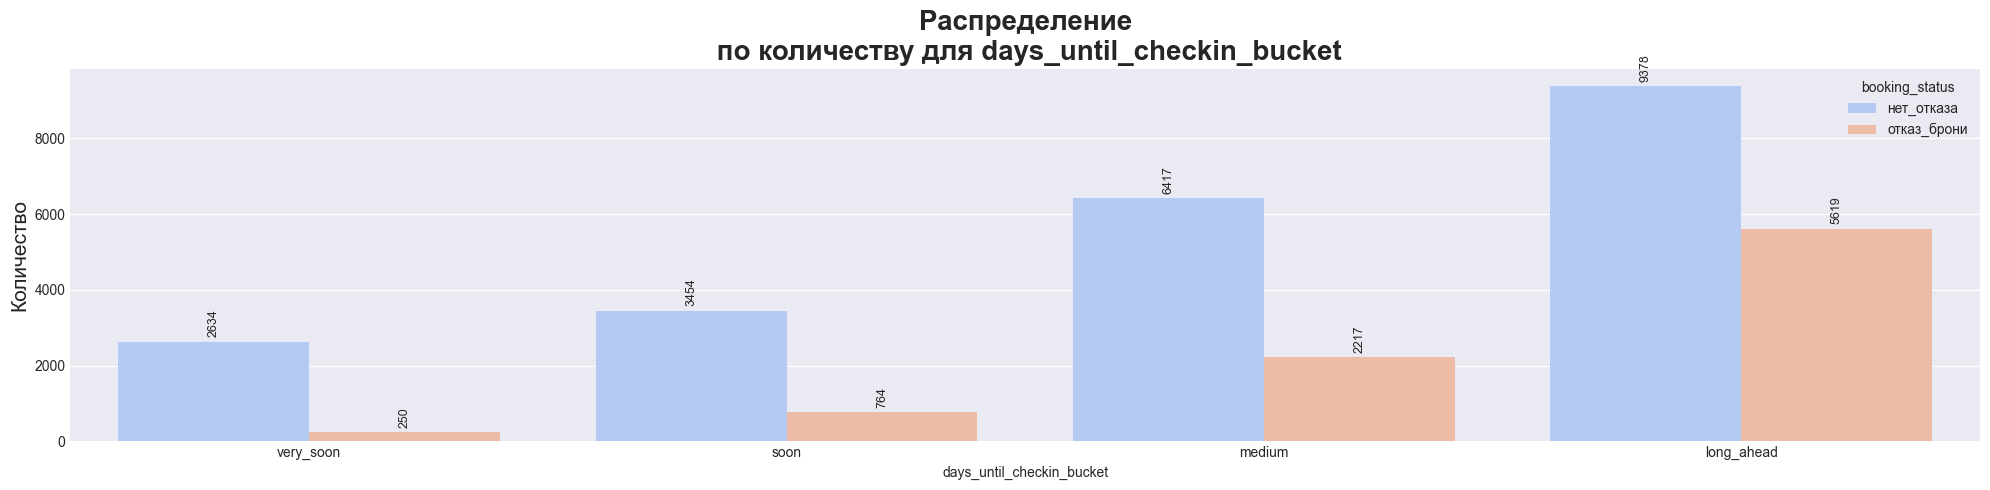

In [38]:
# Список новых признаков
new_columns = [
    'total_nights',
    'price_per_guest_per_night',
]

# Выводим графики для новых числовых признаков
for new_col in new_columns:
    _, axes = plt.subplots(1, 3, figsize=(20, 7))
    print_histplot(df_merge_booking_with_features, new_col, axes[0])
    print_countplot(df_merge_booking_with_features, new_col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_merge_booking_with_features, new_col, axes[2])

# Выводим график для нового категориального признака
_, axes = plt.subplots(1, 1, figsize=(20, 5))
print_countplot(df_merge_booking_with_features, 'days_until_checkin_bucket', axes, 'booking_status', 'coolwarm')

plt.tight_layout()
plt.show()

## [Этап 2: Моделированиех <a id=2></a>](#content)

### [2.1 Обучение базовых моделий <a id=2_1></a>](#content)

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

In [39]:
# Выделяем целевой признак
label_map = {'нет_отказа': 0, 'отказ_брони': 1}
X = df_merge_booking.drop(columns=['booking_status', 'booking_id', 'customer_id'])
y = df_merge_booking['booking_status'].map(label_map)

# Разделяем данные на Обучающую, калибровочную и тестовую выборки
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
) 

X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_cal
)

# Выводим информацию о размерах выборок
print(f" Train: {X_train.shape}\n Cal:   {X_cal.shape}\n Test:  {X_test.shape}")

 Train: (18439, 18)
 Cal:   (6147, 18)
 Test:  (6147, 18)


In [40]:
# Создаем пустой датафрейм с метриками
metrics_result_df = pd.DataFrame(
    columns=[
        'Accuracy', 
        'Precision', 
        'Recall', 
        'F1-score', 
        'AUC-ROC', 
        'TP', 
        'FP', 
        'FN', 
        'TN', 
        'Экономические потери'
    ]
).astype({
    'Accuracy': 'float64',
    'Precision': 'float64',
    'Recall': 'float64',
    'F1-score': 'float64',
    'AUC-ROC': 'float64',
    'TP': 'int64',
    'FP': 'int64',
    'FN': 'int64',
    'TN': 'int64',
    'Экономические потери': 'int64'
})

# Создаем пустой словарь для хранения обученых моделей
all_model_dict = {}

# Определяем числовые и категориальные признаки
numeric_cols_booking_merge = df_merge_booking.select_dtypes(include=[np.number, 'bool']).columns.to_list()
category_cols_booking_merge = df_merge_booking.select_dtypes(include=['str', 'object']).columns.to_list()
dt_cols_booking_merge = df_merge_booking.select_dtypes(include='datetime64').columns.to_list()

In [41]:
# Функция для расчета метрик
def metrics_calc(y_true, y_pred, y_proba):
    '''
    Функция для рассчета метрик
    '''
    # Матрица ошибок
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Расчет экономического эффекта
    cost_fp = 7000  
    lost_rev = 64500 
    economic_loss = (fp * cost_fp) + (fn*lost_rev)

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Экономические потери': economic_loss
    }

    return metrics


In [42]:
# Функция для добавления метрик в список
def add_metrics(metrics_result_df, model_name, y_true, y_pred, y_proba, all_model_dict=None):
    '''
    Функция для добавления метрик их в общий датафрейм для сравнения
    '''

    metrics = metrics_calc(y_true, y_pred, y_proba)
    metrics['Модель'] = model_name

    # Добавляем новую строку в metrics_result_df
    metrics_result_df.loc[model_name] = metrics
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)

In [43]:
def fit_predict_model(model, name_model, X_train, y_train, X_test, y_test):
    """
    Обучает ML-модель, рассчитывает прогноз
    на валидационной выборке и сохраняет метрики и саму модель.
    """    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Выводим значения метрик
    add_metrics(metrics_result_df, name_model, y_test, y_pred, y_proba[:, 1])
    all_model_dict[name_model] = model

In [44]:
# Создание числового пайплайна
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Создание категориального пайплайна
category_pipe = Pipeline(steps=[
    ('one', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Создаем пайплайны для моделей
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', category_pipe, make_column_selector(dtype_include=['object', 'category', 'string']))
    ],
    remainder='passthrough'
)

# Создание базового пайплайна
def create_pipeline(model):
    return Pipeline([
        ('add_features', FunctionTransformer(add_booking_features, validate=False)),
        ('extract_time', FunctionTransformer(extract_time_features, validate=False)),
        ('extraction_text', FunctionTransformer(feature_extraction_text, validate=False)),
        ('preprocessor', preprocessor),
        ('model', model)
    ])

In [45]:
def fit_predict_cv(model, name_model, X_train, y_train, metrics_result_df, all_model_dict=None):
    """
    Обучает модель через кросс-валидацию, считает средние метрики по фолдам
    и записывает одну строку в metrics_result_df.
    Модель обученную на всём train, сохраняет в all_model_dict.
    """
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    fold_metrics = []
    val_size = 2000

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_temp = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_temp = y_train.iloc[train_idx], y_train.iloc[val_idx]
        # Ограничиваем валидационную выборку до 2000 строк
        X_val = X_temp.sample(n=val_size, random_state=RANDOM_STATE)
        y_val = y_temp.loc[X_val.index]

        pipe = clone(model)
        pipe.fit(X_tr, y_tr)

        y_pred = pipe.predict(X_val)
        y_proba = pipe.predict_proba(X_val)[:, 1]

        fold_metrics.append(metrics_calc(y_val, y_pred, y_proba))

    # Усредняем метрики по фолдам
    avg_series = pd.DataFrame(fold_metrics).mean(numeric_only=True)

    # Преобразуем только нужные колонки в int (счётчики и потери)
    int_cols = ['TP', 'FP', 'FN', 'TN', 'Экономические потери']
    for col in int_cols:
        if col in avg_series.index:
            avg_series[col] = int(round(avg_series[col]))

    avg_metrics = avg_series.to_dict()
    avg_metrics['Модель'] = name_model

    # Добавляем новую строку в metrics_result_df
    metrics_result_df.loc[name_model] = avg_metrics
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)
    

In [46]:
lightgbm_base = create_pipeline(
    LGBMClassifier(
        random_state=RANDOM_STATE
    )
)

fit_predict_cv(
    lightgbm_base,
    'LGBMClassifier_Base',
    X_train,
    y_train,
    metrics_result_df
)

[LightGBM] [Info] Number of positive: 3540, number of negative: 8752
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3680
[LightGBM] [Info] Number of data points in the train set: 12292, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.287992 -> initscore=-0.905156
[LightGBM] [Info] Start training from score -0.905156
[LightGBM] [Info] Number of positive: 3540, number of negative: 8753
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3381
[LightGBM] [Info] Number of data points in the train set: 12293, number of used features: 90
[LightGBM] [Info] [bin

In [47]:
metrics_result_df

,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Экономические потери
LGBMClassifier_Base,0.83,0.76,0.61,0.68,0.90,356.00,110.00,228.00,1 306.00,15 456 833.00


### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.